# 🍱 Malaysian Food Classification: Custom CNN
---
This notebook implements a Custom Convolutional Neural Network (CNN) in PyTorch to classify Malaysian food categories. 

###  Setup Details:
- **Framework**: PyTorch
- **Device**: NVIDIA GPU (CUDA)
- **Classes**: ayam_goreng, burger, curry_puff, laksa, rice
- **Imbalance Strategy**: WeightedRandomSampler

In [1]:
import os, random, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, utils
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


##  Configuration & Hyper-parameters

In [2]:
DATA_DIR    = Path(".")  # Folders are in the root directory
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-3
NUM_CLASSES = 5
CLASS_NAMES = ["ayam_goreng", "burger", "curry_puff", "laksa", "rice"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

##  Data Loading & Augmentation

In [3]:
def get_transforms():
    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, val_tf

train_tf, val_tf = get_transforms()

print("[INFO] Loading datasets from folders...")
train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_DIR / "val",   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_DIR / "test",  transform=val_tf)

# ── Handle Class Imbalance ──
print("[INFO] Calculating class weights for balancing...")
targets = train_ds.targets
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"  - Training images:   {len(train_ds)} (Balanced via Sampler)")
print(f"  - Validation images: {len(val_ds)}")
print(f"  - Testing images:    {len(test_ds)}")

[INFO] Loading datasets from folders...
[INFO] Calculating class weights for balancing...
  - Training images:   794 (Balanced via Sampler)
  - Validation images: 98
  - Testing images:    104


###  Visualize Augmented Data
Run this cell to see what the model actually "sees" during training after all the transformations.

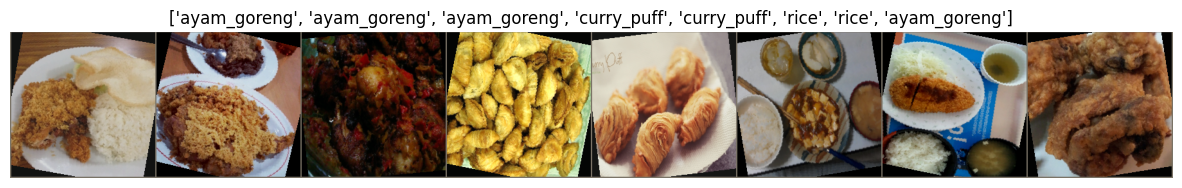

In [4]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = utils.make_grid(inputs[:8])

plt.figure(figsize=(15, 5))
imshow(out, title=[CLASS_NAMES[x] for x in classes[:8]])
plt.show()

In [5]:
import torch
from collections import Counter
import numpy as np

# 1. Get current distribution from training dataset targets
targets = np.array(train_ds.targets)
original_counts = Counter(targets)

print("--- Original Class Distribution ---")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:12}: {original_counts[i]} images")

# 2. Show the weights being applied
# Higher weights for minority classes, lower for 'rice' (the majority)
counts = np.bincount(targets)
weights = 1. / counts
print(f"\nComputed Class Weights (Inverses):\n{weights}")

# 3. Simulate an actual training epoch using the sampler
# We convert the sampler to a list to trigger the random selection process
sampled_indices = list(sampler)
simulated_labels = [targets[i] for i in sampled_indices]

balanced_counts = Counter(simulated_labels)

print(f"\n--- Distribution After WeightedRandomSampler (Full Epoch Simulation) ---")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:12}: {balanced_counts[i]} times")


--- Original Class Distribution ---
ayam_goreng : 122 images
burger      : 124 images
curry_puff  : 90 images
laksa       : 82 images
rice        : 376 images

Computed Class Weights (Inverses):
[0.00819672 0.00806452 0.01111111 0.01219512 0.00265957]

--- Distribution After WeightedRandomSampler (Full Epoch Simulation) ---
ayam_goreng : 151 times
burger      : 157 times
curry_puff  : 171 times
laksa       : 145 times
rice        : 170 times


##  Custom CNN Architecture

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
        
    def forward(self, x): return self.block(x)

class MalaysianFoodCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),    # 224 -> 112
            ConvBlock(32, 64),   # 112 -> 56
            ConvBlock(64, 128),  # 56 -> 28
            ConvBlock(128, 256), # 28 -> 14
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.classifier(x)
        return x

model = MalaysianFoodCNN(NUM_CLASSES).to(DEVICE)
print("[INFO] Model initialized.")

[INFO] Model initialized.


architecture analysis

In [7]:
try:
    from torchsummary import summary
    print("[INFO] Generating model summary...")
    summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))
except ImportError:
    !pip install torchsummary
    from torchsummary import summary
    summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))

[INFO] Generating model summary...
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             864
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
            Conv2d-4         [-1, 32, 224, 224]           9,216
       BatchNorm2d-5         [-1, 32, 224, 224]              64
              ReLU-6         [-1, 32, 224, 224]               0
         MaxPool2d-7         [-1, 32, 112, 112]               0
         ConvBlock-8         [-1, 32, 112, 112]               0
            Conv2d-9         [-1, 64, 112, 112]          18,432
      BatchNorm2d-10         [-1, 64, 112, 112]             128
             ReLU-11         [-1, 64, 112, 112]               0
           Conv2d-12         [-1, 64, 112, 112]          36,864
      BatchNorm2d-13         [-1, 64, 112, 112]             128
    

In [8]:
def calculate_receptive_field():
    # Receptive Field (RF) formula: RF_out = RF_in + (k - 1) * stride_prod
    # stride_prod is the product of all previous strides
    rf = 1
    stride_prod = 1
    
    print(f"{'Layer':<20} | {'Kernel':<6} | {'Stride':<6} | {'Receptive Field':<15}")
    print("-" * 55)
    
    # Define the sequence of layers that affect RF (Conv2d and MaxPool2d)
    # Based on the MalaysianFoodCNN and ConvBlock structure:
    # Each ConvBlock has: Conv(3x3, s1), Conv(3x3, s1), MaxPool(2x2, s2)
    layers = []
    for i in range(4): # 4 ConvBlocks
        layers.append(("Conv2d", 3, 1))
        layers.append(("Conv2d", 3, 1))
        layers.append(("MaxPool2d", 2, 2))

    for name, k, s in layers:
        rf = rf + (k - 1) * stride_prod
        stride_prod *= s
        print(f"{name:<20} | {k:<6} | {s:<6} | {rf:<15}")

    print(f"\nFinal Receptive Field before Global Average Pooling: {rf}x{rf} pixels")
    print(f"Note: Since the input is {IMG_SIZE}x{IMG_SIZE}, a RF of {rf} means the network 'sees' a significant portion of the image.")

calculate_receptive_field()

Layer                | Kernel | Stride | Receptive Field
-------------------------------------------------------
Conv2d               | 3      | 1      | 3              
Conv2d               | 3      | 1      | 5              
MaxPool2d            | 2      | 2      | 6              
Conv2d               | 3      | 1      | 10             
Conv2d               | 3      | 1      | 14             
MaxPool2d            | 2      | 2      | 16             
Conv2d               | 3      | 1      | 24             
Conv2d               | 3      | 1      | 32             
MaxPool2d            | 2      | 2      | 36             
Conv2d               | 3      | 1      | 52             
Conv2d               | 3      | 1      | 68             
MaxPool2d            | 2      | 2      | 76             

Final Receptive Field before Global Average Pooling: 76x76 pixels
Note: Since the input is 224x224, a RF of 76 means the network 'sees' a significant portion of the image.


##  Training Loop

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

import json
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("[INFO] Starting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    train_loss = train_loss / len(train_ds)
    train_acc = train_correct.double() / len(train_ds)
    val_loss = val_loss / len(val_ds)
    val_acc = val_correct.double() / len(val_ds)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc.item())
    history['val_acc'].append(val_acc.item())
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\n[INFO] Training complete in {total_time/60:.2f} minutes")

with open("custom_cnn_results.json", "w") as f:
    json.dump({"history": history, "total_time": total_time}, f)


[INFO] Starting training...
Epoch 1/30 | Train Loss: 1.4322 Acc: 0.3438 | Val Loss: 1.1899 Acc: 0.5102
Epoch 2/30 | Train Loss: 1.2239 Acc: 0.4685 | Val Loss: 1.0672 Acc: 0.5102
Epoch 3/30 | Train Loss: 1.2682 Acc: 0.4824 | Val Loss: 0.9725 Acc: 0.5918
Epoch 4/30 | Train Loss: 1.1516 Acc: 0.5176 | Val Loss: 1.2318 Acc: 0.5204
Epoch 5/30 | Train Loss: 1.1195 Acc: 0.5302 | Val Loss: 1.2536 Acc: 0.4796
Epoch 6/30 | Train Loss: 1.0314 Acc: 0.5957 | Val Loss: 1.3044 Acc: 0.6020
Epoch 7/30 | Train Loss: 1.0232 Acc: 0.5844 | Val Loss: 1.0401 Acc: 0.6327
Epoch 8/30 | Train Loss: 0.9085 Acc: 0.6335 | Val Loss: 1.0096 Acc: 0.6122
Epoch 9/30 | Train Loss: 0.8656 Acc: 0.6574 | Val Loss: 1.2071 Acc: 0.4796
Epoch 10/30 | Train Loss: 0.8016 Acc: 0.6587 | Val Loss: 1.0025 Acc: 0.6939
Epoch 11/30 | Train Loss: 0.7926 Acc: 0.7053 | Val Loss: 0.8118 Acc: 0.6735
Epoch 12/30 | Train Loss: 0.7625 Acc: 0.7078 | Val Loss: 1.1469 Acc: 0.5306
Epoch 13/30 | Train Loss: 0.7338 Acc: 0.7305 | Val Loss: 0.9454 Acc: 

##  Visualization & Evaluation

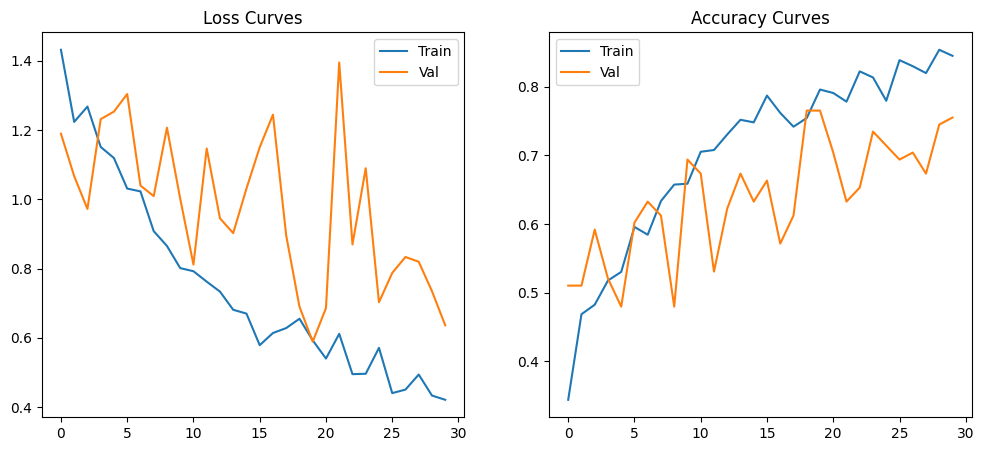

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

[INFO] Evaluating on Test Set...
              precision    recall  f1-score   support

 ayam_goreng       0.73      0.69      0.71        16
      burger       0.82      0.53      0.64        17
  curry_puff       0.45      0.75      0.56        12
       laksa       0.67      0.91      0.77        11
        rice       0.95      0.85      0.90        48

    accuracy                           0.77       104
   macro avg       0.72      0.75      0.72       104
weighted avg       0.81      0.77      0.78       104



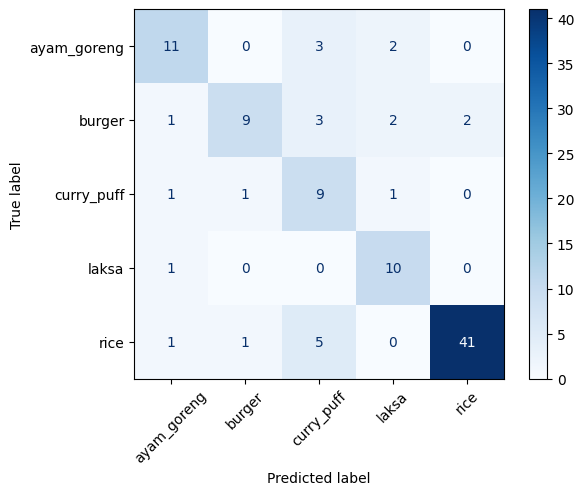

In [11]:
print("[INFO] Evaluating on Test Set...")
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.show()

###  Visualize Predictions
Run this cell to see some random test images and what the model predicts for them.

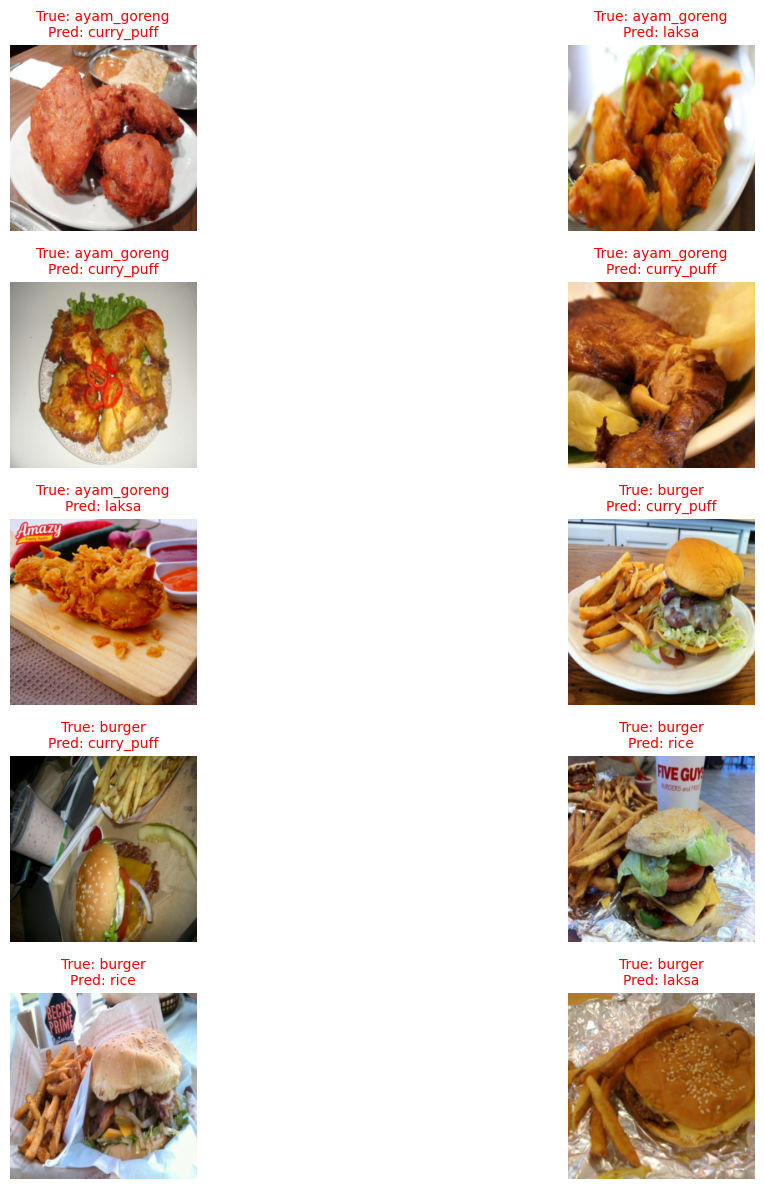

In [ ]:
def visualize_misclassified(model, num_images=10):
    was_training = model.training
    model.eval()
    images_so_far = 0
    # Adjusted figure size for a horizontal layout
    plt.figure(figsize=(20, 4))

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                # Only process if prediction is wrong
                if preds[j] != labels[j]:
                    images_so_far += 1

                    # Create a horizontal layout: 1 row, num_images columns
                    ax = plt.subplot(1, num_images, images_so_far)
                    ax.axis('off')

                    title = f'True: {CLASS_NAMES[labels[j]]}\nPred: {CLASS_NAMES[preds[j]]}'
                    ax.set_title(title, color='red', fontsize=9, pad=10)
                    imshow(inputs.cpu().data[j])

                    if images_so_far == num_images:
                        model.train(mode=was_training)
                        plt.tight_layout()
                        plt.show()
                        return

        if images_so_far == 0:
            print("No misclassified samples found in the test set!")
        model.train(mode=was_training)

# Visualize 5-10 mistakes in a horizontal row
visualize_misclassified(model, num_images=10)